# DATA PREPARATION

In [1]:
# INITIATION: PYTHON AND DISPLAY

# Import libraries
import pandas as pd #
import numpy as np
import matplotlib.pyplot as plt #charts
import seaborn as sns #charts

# For better visibility
from IPython.display import display, HTML

# Apply a no-wrap style to prevent text wrapping
display(HTML("""
<style>
.dataframe td { white-space: nowrap; }
</style>
"""))

# Set the option to display all columns
pd.set_option('display.max_columns', None)

# Set the option to display all rows
pd.set_option('display.max_rows', None)

# Set the float format to use a space as a thousands separator and a comma as a decimal separator
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' ').replace('.', ','))

In [4]:
# FILE LOAD

# Read the Excel file into a DataFrame
df = pd.read_excel('2000 Analysis Python.xlsx', usecols=list(range(1, 29)), decimal=',')

pkd = pd.read_excel('pkd2007.xlsx')  # Load the pkd data

companies = pd.read_excel('Companies.xlsx')

# Merge the pkd data into the df dataframe
df = pd.merge(
    df,
    pkd,
    left_on=df['PKD'].astype(str).str[:2].astype(int),
    right_on='Number',
    how='left'
)

# Select the columns and make a copy to avoid the SettingWithCopyWarning
columns_to_select = [4, 0, 1, 2, 3]

companies_subset = companies.iloc[:, columns_to_select].copy()

# Rename the columns with meaningful names
companies_subset.columns = ['Name', 'L2022', 'L2021', 'L2020', 'L2019']

# Ensure 'Name' columns are of the same data type
df['Name'] = df['Name'].astype(str)
companies_subset['Name'] = companies_subset['Name'].astype(str)

# Perform the merge
df = pd.merge(
    df,
    companies_subset,
    on='Name',
    how='left'
)

In [5]:
# FILE INSPECTION

# Print the number of rows and columns
print(f"Number of rows and columns: {df.shape}")

# Display the first 5 rows of the DataFrame
display(df.head())

# Print the last 5 rows of the DataFrame
display(df.tail())

Number of rows and columns: (8136, 36)


,Name,GPW,Funded KRS,Funded Business,Foreign Branches,PKD,Owner Type,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,Salaries,Salary related,BS,Fixed Assets,Current Assets,Equity,Liabilities,Export as % of sales,ROA,ROS,ROE,List,Letter,Letter Description,Number,Number Description,L2022,L2021,L2020,L2019
0,"Orlen SA GK, Płock",SG),"1 999,00","1 944,00",Tak,1920,412,2022,"277 564 000,00","41 093 000,00","40 593 000,00","33 630 000,00","6 916 000,00","114 120 000,00","64 494,00","6 406 000,00","5 385 000,00","1 021 000,00","272 327 000,00","153 117 000,00","119 210 000,00","136 959 000,00","135 368 000,00","0,41","0,12","0,15","0,25",Yes,C,Manufacturing,19,WYTWARZANIE I PRZETWARZANIE KOKSU I PRODUKTÓW ...,1,"1,00","1,00","1,00"
1,"Jeronimo Martins Polska SA, Kostrzyn",NaN,"1 995,00",NaN,NaN,4719,500,2022,"85 034 775,00","4 109 337,00","4 254 158,00","3 414 175,00","1 207 337,60","0,00","77 726,70","5 186 427,00","4 171 040,00","1 015 387,00","23 866 577,00","10 897 620,00","12 968 957,00","4 653 067,00","18 097 341,00","0,00","0,14","0,05","0,73",Yes,G,Wholesale and Retail Trade; Repair of Motor Ve...,47,"HANDEL DETALICZNY, Z WYŁĄCZENIEM HANDLU DETALI...",2,"3,00","2,00","2,00"
2,"PGE Polska Grupa Energetyczna GK SA, Lublin",SG),"2 007,00","1 990,00",NaN,7010,145,2022,"73 435 000,00","4 299 000,00","4 110 000,00","3 390 000,00","1 103 000,00","29 000,00","38 013,00","5 033 000,00","4 224 000,00","809 000,00","105 778 000,00","71 732 000,00","34 046 000,00","54 383 000,00","51 395 000,00","0,00","0,03","0,06","0,06",Yes,M,"Professional, Scientific and Technical Activities",70,DZIAŁALNOŚĆ FIRM CENTRALNYCH (HEAD OFFICES); D...,3,"4,00","3,00","4,00"
3,"LG Energy Solution Wrocław sp. z o.o., Wrocław",NaN,"2 016,00",NaN,NaN,2720,500,2022,"40 736 584,00","2 273 691,00","1 892 236,00","1 772 021,00","2 053 927,00","33 690 570,00","7 154,00","967 979,00","760 145,00","207 834,00","34 420 555,00","17 242 707,00","17 177 848,00","6 746 432,00","23 448 517,00","0,83","0,05","0,06","0,26",Yes,C,Manufacturing,27,PRODUKCJA URZĄDZEŃ ELEKTRYCZNYCH,4,"8,00","14,00","45,00"
4,"Totalizator Sportowy sp. z o.o. GK, Warszawa",NaN,"1 956,00",NaN,NaN,9200,100,2022,"39 425 832,00","423 173,00","451 477,00","363 507,00","135 259,00","0,00","5 354,00","609 740,50","486 298,50","123 442,00","2 614 625,50","953 078,00","1 661 547,50","1 545 806,00","982 775,00","0,00","0,14","0,01","0,24",Yes,R,"Arts, Entertainment and Recreation",92,DZIAŁALNOŚĆ ZWIĄZANA Z GRAMI LOSOWYMI I ZAKŁAD...,5,"11,00","17,00","30,00"


,Name,GPW,Funded KRS,Funded Business,Foreign Branches,PKD,Owner Type,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,Salaries,Salary related,BS,Fixed Assets,Current Assets,Equity,Liabilities,Export as % of sales,ROA,ROS,ROE,List,Letter,Letter Description,Number,Number Description,L2022,L2021,L2020,L2019
8131,"Albea Poland sp. z o.o., Łódź",NaN,NaN,NaN,NaN,2229,500,2019,"320 844,00","28 137,00","29 254,00","22 720,00","16 641,00","247 698,00","647,00","56 245,00","44 790,00","11 455,00","243 973,00","150 708,00","93 266,00","170 654,00","67 836,00","0,77","0,09","0,09","0,13",No,C,Manufacturing,22,PRODUKCJA WYROBÓW Z GUMY I TWORZYW SZTUCZNYCH,NaN,NaN,"1 717,00","1 807,00"
8132,"Flokk sp. z o.o., Turek",NaN,"2 017,00",NaN,NaN,3101,500,2019,"441 486,85","28 565,00","27 122,00","30 298,00","21 165,00","327 390,00","1 376,00","105 927,00","87 162,00","18 765,00","534 159,00","320 722,00","213 437,00","461 552,00","43 028,00","0,74","0,06","0,06","0,07",No,C,Manufacturing,31,PRODUKCJA MEBLI,NaN,"1 897,00","1 855,00","1 286,00"
8133,"Stalexport Autostrady SA GK, Katowice",NaN,"1 963,00",NaN,NaN,4211,540,2019,"351 487,00","129 153,00","124 772,00","80 396,00","57 005,00","0,00","335,00",NaN,NaN,NaN,"1 322 052,00","918 245,00","403 807,00","795 764,00","526 288,00","0,00","0,06","0,37","0,10",No,F,Construction,42,ROBOTY ZWIĄZANE Z BUDOWĄ OBIEKTÓW INŻYNIERII L...,NaN,NaN,"1 887,00","1 645,00"
8134,Konica Minolta Business Solutions Polska sp. z...,NaN,"1 991,00","1 878,00",2023,4666,500,2019,"375 672,00","8 973,00","146,00","449,00","47 474,00","5 807,00","396,00","68 204,70","56 243,70","11 961,00","417 658,00","227 601,00","190 056,00","79 721,00","325 250,00","0,02","0,00","0,02","0,01",No,G,Wholesale and Retail Trade; Repair of Motor Ve...,46,"HANDEL HURTOWY, Z WYŁĄCZENIEM HANDLU POJAZDAMI...",NaN,NaN,"1 829,00","1 544,00"
8135,"Fuji Seal Poland sp. z o.o., Kutno",NaN,NaN,NaN,NaN,2222,500,2019,"291 940,00","10 828,00","9 548,00","9 298,00","21 803,00","266 026,00","454,00","43 340,13","34 655,13","8 685,00","291 405,00","225 927,00","65 478,00","159 252,00","119 461,00","0,91","0,03","0,04","0,06",No,C,Manufacturing,22,PRODUKCJA WYROBÓW Z GUMY I TWORZYW SZTUCZNYCH,NaN,"1 773,00","1 721,00","1 958,00"


In [6]:
# DATA CLEAN-UP

# Step 1: Identify duplicates based on 'Name' and 'Year' columns
duplicates = df[df.duplicated(subset=['Name', 'Year'], keep=False)]

# Step 2: Display the duplicates for inspection
print("Duplicate rows based on 'Name' and 'Year':")
print(duplicates)

Duplicate rows based on 'Name' and 'Year':
Empty DataFrame
Columns: [Name, GPW, Funded KRS, Funded Business, Foreign Branches, PKD, Owner Type, Year, Sales, Gross Profit, Operating Profit, Net Profit, Depreciation, Export Sales, Employment, Staff costs, Salaries, Salary related, BS, Fixed Assets, Current Assets, Equity, Liabilities, Export as % of sales, ROA, ROS, ROE, List, Letter, Letter Description, Number, Number Description, L2022, L2021, L2020, L2019]
Index: []


In [7]:
#DATA TYPES ASSIGNMENT

# Step 1: Changing data types for analysis
dtype_changes = {
    'List': 'category',
    'PKD': 'category',
    'Number': 'category',
    'Letter': 'category',
    'Owner Type': 'category',
    'Year': 'category',
    'Sales': 'float',
    'Gross Profit': 'float',
    'Operating Profit': 'float',
    'Net Profit': 'float',
    'Depreciation': 'float',
    'Export Sales': 'float',
    'Employment': 'float',
    'Staff costs': 'float',
    'Salaries': 'float',
    'Salary related': 'float',
    'BS': 'float',
    'Operating Profit': 'float',
    'Fixed Assets': 'float',
    'Current Assets': 'float',
    'Equity': 'float',
    'Liabilities': 'float',
    'Export as % of sales': 'float',
    'ROA': 'float',
    'ROS': 'float',
    'ROE': 'float',
    'L2022': 'float'
    
    
    }
# Step 2: Check each column individually to identify possible issues

for col, dtype in dtype_changes.items():
    try:
        if dtype in ['float', 'int']:  # Check if the target type is numeric
            df[col] = pd.to_numeric(df[col], errors='coerce')  # Use pd.to_numeric for numeric conversion
        df[col] = df[col].astype(dtype)  # Convert to the target dtype
        print(f"Successfully converted {col} to {dtype}")
    except ValueError as e:
        print(f"Error converting {col} to {dtype}: {e}")


Successfully converted List to category
Successfully converted PKD to category
Successfully converted Number to category
Successfully converted Letter to category
Successfully converted Owner Type to category
Successfully converted Year to category
Successfully converted Sales to float
Successfully converted Gross Profit to float
Successfully converted Operating Profit to float
Successfully converted Net Profit to float
Successfully converted Depreciation to float
Successfully converted Export Sales to float
Successfully converted Employment to float
Successfully converted Staff costs to float
Successfully converted Salaries to float
Successfully converted Salary related to float
Successfully converted BS to float
Successfully converted Fixed Assets to float
Successfully converted Current Assets to float
Successfully converted Equity to float
Successfully converted Liabilities to float
Successfully converted Export as % of sales to float
Successfully converted ROA to float
Successfully

In [8]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8136 entries, 0 to 8135
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Name                  8136 non-null   object  
 1   GPW                   548 non-null    object  
 2   Funded KRS            1564 non-null   float64 
 3   Funded Business       220 non-null    float64 
 4   Foreign Branches      248 non-null    object  
 5   PKD                   8136 non-null   category
 6   Owner Type            8136 non-null   category
 7   Year                  8136 non-null   category
 8   Sales                 8109 non-null   float64 
 9   Gross Profit          8051 non-null   float64 
 10  Operating Profit      8057 non-null   float64 
 11  Net Profit            8071 non-null   float64 
 12  Depreciation          8040 non-null   float64 
 13  Export Sales          7963 non-null   float64 
 14  Employment            7977 non-null   float64 
 15  Staf

None

# ANALYSIS  SET-UP

In [9]:
#SET THE MAIN FILTERS FOR THE ANALYSIS

#filter companies
company_filter = df[df['Number'] == 19] #filter out fuel companies

# Identify the names with Sales = 0 or Employment = 0 in 2019 or 2022
names_to_remove = df[
    (df['Year'].isin([2019, 2022])) & 
    (
        (df['Sales'] == 0) | pd.isnull(df['Sales']) |
        (df['Employment'] == 0) | pd.isnull(df['Employment'])
    )
]['Name'].unique()

# Apply the filters
df_filter = df[
    df['L2022'].notna() &
    (~df['Name'].isin(names_to_remove))
]

df_filter = df_filter[~df_filter.index.isin(company_filter.index)]

# Show results

print(f"Number of companies removed due to sector considerations is: {company_filter['Name'].nunique()}")
print(f"Number of companies with sales or employment in 2019 or 2022 equal to 0 is: {len(names_to_remove)}")
print(f"Number of companies, which did not appear on the 2000 List in 2022 is: {len(df[df['List'] == 'No'])}")

print(f"Number of companies with sales or employment in 2019 or 2022 equal to 0 after clean-up is: {len(df_filter[df_filter['Sales'] == 'No'])}")
print(f"Number of companies, which did not appear on the 2000 List in 2022 after is: {len(df_filter[df_filter['List'] == 'No'])}")

print(f"Number of companies after clean-up: {len(df_filter[df_filter['Year'] == 2022]['Sales'])}")

Number of companies removed due to sector considerations is: 9
Number of companies with sales or employment in 2019 or 2022 equal to 0 is: 115
Number of companies, which did not appear on the 2000 List in 2022 is: 138
Number of companies with sales or employment in 2019 or 2022 equal to 0 after clean-up is: 0
Number of companies, which did not appear on the 2000 List in 2022 after is: 0
Number of companies after clean-up: 1861


In [10]:
#Lista firm usuniętych z analizy
df_print = df[df['Name'].isin(names_to_remove)]

display(df_print.pivot(index='Name', columns='Year', values='Sales'))
df_print.to_excel('filtered_data.xlsx', index=False)  # Save the filtered DataFrame to an Excel file

Year,2019,2020,2021,2022
Name,,,,
"7R Development Management sp. z o.o., Kraków","104 909,00","406 831,44","406 831,44","456 893,50"
"Accenture sp. z o.o. GK, Warszawa",NaN,NaN,"1 586 932,00","2 095 218,00"
"Agro Kontrakt sp. z o.o., Olsztyn","0,00","0,00","675,00","611 978,40"
"Aquila Radomsko sp. z o.o., Radomsko","251 800,00","242 966,00","342 096,93","407 942,00"
"Aramco Fuels Poland sp. z o.o., Gdańsk","0,00","0,00","0,00","5 033 149,00"
"Archigrest sp. z o.o., Warszawa",NaN,NaN,"439 219,00","578 535,00"
"B8 sp. z o.o. Baltic sp.k.a., Gdańsk","274 092,94","327 867,00","266 965,95","458 564,44"
"Baywa R.E. Solar Systems sp. z o.o., Zabierzów","0,00","0,00","298 812,06","743 669,00"
"Benzol sp. z o.o., Ostrołęka","235 198,98","190 145,48","281 486,18","421 783,12"


In [11]:
#CHECK OF FILTERING

# Select the columns you want to include in the groupby and describe operations
selected_columns = ['Sales', 'Employment']

# Group by 'P/F' and 'Year' and apply describe to the selected columns only
df_summary = df.groupby(['Year'], observed=False)[selected_columns].describe().transpose()
df_filter_summary = df_filter.groupby(['Year'], observed=False)[selected_columns].describe().transpose()
display(df_summary, df_filter_summary)

# Show max and min company
selected_columns = ['Name','Sales', 'Employment']
display(df_filter['Name'].nunique())
display(df_filter.loc[df_filter['Sales'].idxmax(),selected_columns])
display(df_filter.loc[df_filter[df_filter['Year'] == 2022]['Sales'].idxmin(),selected_columns])

display(df[selected_columns].head())

Year                       2019          2020           2021           2022
Sales      count       2 017,00      2 026,00       2 032,00       2 034,00
           mean    1 185 203,11  1 201 930,70   1 479 562,02   1 953 531,56
           std     3 523 189,91  3 302 545,96   4 302 033,93   7 387 258,01
           min             0,00          0,00           0,00     368 609,79
           25%       316 485,28    327 677,48     412 518,24     525 459,10
           50%       501 741,00    508 354,11     628 892,35     796 314,88
           75%       957 376,00    961 828,50   1 151 565,25   1 426 674,68
           max   111 203 000,00 86 180 000,00 131 341 000,00 277 564 000,00
Employment count       1 985,00      1 991,00       2 003,00       1 998,00
           mean        1 301,41      1 337,15       1 476,20       1 397,51
           std         3 827,95      3 992,54       6 088,64       4 174,72
           min             0,00          0,00           0,00           0,00
           25%           151,00        159,00         177,50         188,25
           50%           440,00        452,00         476,00         480,00
           75%         1 037,00      1 063,50       1 109,50       1 127,00
           max        80 116,00     78 873,00     206 512,00      77 726,70

Year                      2019          2020          2021          2022
Sales      count      1 861,00      1 861,00      1 860,00      1 861,00
           mean   1 158 623,21  1 183 644,38  1 434 100,72  1 834 332,99
           std    2 580 432,72  2 748 345,13  3 228 955,17  4 234 002,71
           min          166,51     14 316,00     19 803,78    368 609,79
           25%      328 825,00    339 322,75    418 463,87    529 531,08
           50%      511 874,00    522 516,00    637 843,48    797 783,58
           75%      972 338,00    970 655,10  1 151 565,25  1 415 703,00
           max   55 573 747,04 61 216 804,38 68 246 695,47 85 034 775,00
Employment count      1 861,00      1 859,00      1 859,00      1 861,00
           mean       1 325,02      1 353,34      1 489,41      1 383,85
           std        3 885,63      4 021,20      6 231,70      4 009,12
           min            1,00          1,00          1,00          1,00
           25%          171,00        171,50        185,00        195,00
           50%          459,00        468,00        482,00        493,00
           75%        1 080,00      1 106,00      1 119,50      1 131,00
           max       80 116,00     78 873,00    206 512,00     77 726,70

1861

Name          Jeronimo Martins Polska SA, Kostrzyn
Sales                                85 034 775,00
Employment                               77 726,70
Name: 1, dtype: object

Name          Firma Handlowa Rolnik sp.j., Mikołów
Sales                                   368 609,79
Employment                                  344,00
Name: 2033, dtype: object

,Name,Sales,Employment
0,"Orlen SA GK, Płock","277 564 000,00","64 494,00"
1,"Jeronimo Martins Polska SA, Kostrzyn","85 034 775,00","77 726,70"
2,"PGE Polska Grupa Energetyczna GK SA, Lublin","73 435 000,00","38 013,00"
3,"LG Energy Solution Wrocław sp. z o.o., Wrocław","40 736 584,00","7 154,00"
4,"Totalizator Sportowy sp. z o.o. GK, Warszawa","39 425 832,00","5 354,00"


In [12]:
#ADDING ANALYSIS DIMENSIONS

# Polish / Foreign Ownership
# Create a copy of df_filter to avoid the SettingWithCopyWarning
df_filter = df_filter.copy()

# Polish / Foreign Companies
df_filter['P/F'] = np.where((df_filter['Owner Type'].astype(str).str[:1] == '5'), 'F', 'P')
df_filter['P/F'] = df_filter['P/F'].astype('category')

# Starting Profit - ROS in 2019
ros_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['ROS'] # Step 1: Extract 2019 ROS values
df_filter['Starting_Profit'] = df_filter['Name'].map(ros_2019)# Step 2: Map 2019 ROS values to the 'Starting_Profit' column for all rows

# Starting BalanceSheet Strength - Equity / BS in 2019
df_filter['BS'] = df_filter['BS'].replace(0, np.nan) # Replace 0 in the BS column with NaN to avoid division by zero

df_filter['BS_Strength'] = df_filter['Equity'] / df_filter['BS']
bs_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['BS_Strength'] # Step 1: Extract 2019 BS_Strength values
df_filter['Starting_BS_Strength'] = df_filter['Name'].map(bs_2019)# Step 2: Map 2019 ROS values to the 'Starting_Profit' column for all rows


# Starting Size - ln sales in 2019
ln_sales_2019 = df_filter[df_filter['Year'] == 2019].set_index('Name')['Sales'].apply(np.log)  # Step 1: Calculate log(Sales) for 2019
df_filter['Starting_Size'] = df_filter['Name'].map(ln_sales_2019)  # Step 2: Map these values to the 'Starting_Profit' column

# Human Capital Proxy - Staff costs / employment
df_filter['Human_Capital'] = df_filter['Staff costs'] / df_filter['Employment']

#cols = df_filter.columns.tolist()  # Get a list of all column names
#cols.insert(9, cols.pop(cols.index('P/F'))) # Remove 'P/F' and insert it at index 9
#df_filter = df_filter[cols]  # Reassign the DataFrame with the new column order

In [13]:
#SALES
# Isolate the annual growth rate threshold
stability_threshold = 10
growth_threshold = 20 #(72,8% of compound growth between 2019 and 2022)
inflation = 7.5 # (24% inflation between 2019 and 2022, when combined with growth treshold it gives 107% of compund growth)

# Pivot the DataFrame to make year-based comparison easier for both Sales and Export
#(use only with 2022 set as a filter)
pivot_sales = df_filter.pivot(index='Name', columns='Year', values='Sales')
pivot_export_sales = df_filter.pivot(index='Name', columns='Year', values='Export Sales')


# Sales and Employment Growth_2022_2019 (Total Growth)
pivot_sales['SGrowth_2022_2019'] = (pivot_sales[2022] - pivot_sales[2019]) / pivot_sales[2019] * 100
pivot_sales['Annualised_Growth'] = ((pivot_sales[2022] / pivot_sales[2019]) ** (1/3) - 1) * 100
pivot_sales['LSGrowth_2022_2019'] = np.log(pivot_sales[2022] / pivot_sales[2019])


# Stable growth Calculation
pivot_sales['G1'] = ((pivot_sales[2022] / pivot_sales[2019]) ** (1/3) - 1) * 100
pivot_sales['G1'] = pivot_sales['G1'].apply(lambda x: 'Yes' if inflation < x < (stability_threshold + inflation) else 'No')

# Medium Growth Calculation
pivot_sales['G2'] = ((pivot_sales[2022] / pivot_sales[2019]) ** (1/3) - 1) * 100
pivot_sales['G2'] = pivot_sales['G2'].apply(lambda x: 'Yes' if  (stability_threshold + inflation) < x < (growth_threshold+inflation)else 'No')

# High Growth Calculation
pivot_sales['G3'] = ((pivot_sales[2022] / pivot_sales[2019]) ** (1/3) - 1) * 100 > (growth_threshold+inflation)
pivot_sales['G3'] = pivot_sales['G3'].apply(lambda x: 'Yes' if x else 'No')


# High Internationalisation Export Sales > 25% of Sales
pivot_sales['Hint'] = (pivot_export_sales[2022] / pivot_sales[2022]) > 0.25
pivot_sales['Hint'] = pivot_sales['Hint'].apply(lambda x: 'Yes' if x else 'No')

# Sales Drop Conditions
pivot_sales['Drop_Sales'] = (pivot_sales[2020] < pivot_sales[2019]) | (pivot_sales[2021] < pivot_sales[2020]) | (pivot_sales[2022] < pivot_sales[2021])
pivot_sales['Drop_Sales'] = pivot_sales['Drop_Sales'].apply(lambda x: 'Yes' if x else 'No')

# Add Summary Column
def categorize_growth(row):
    if row['Annualised_Growth'] > (growth_threshold + inflation):
        return 'G3'
    elif (stability_threshold + inflation) < row['Annualised_Growth'] <= (growth_threshold + inflation):
        return 'G2'
    elif inflation < row['Annualised_Growth'] <= (stability_threshold + inflation):
        return 'G1'
    else:
        return 'G0'

pivot_sales['Growth_Category'] = pivot_sales.apply(categorize_growth, axis=1)

# Merge the calculated columns back to the original df_filter DataFrame
df_filter = df_filter.merge(pivot_sales[['SGrowth_2022_2019', 'Annualised_Growth', 'LSGrowth_2022_2019', 'Drop_Sales', 'G1', 'G2', 'G3','Growth_Category','Hint']], on='Name')

In [14]:
#EMPLOYMENT
# Pivot the DataFrame to make year-based comparison easier for Employment
#(use only with 2022 set as a filter)
pivot_employment = df_filter.pivot(index='Name', columns='Year', values='Employment')

# Calculate Employment Growth_2022_2019 (Total Growth)
pivot_employment['EGrowth_2022_2019'] = (pivot_employment[2022] - pivot_employment[2019]) / pivot_employment[2019] * 100

# Stable growth calculation
pivot_employment['SE'] = pivot_employment['EGrowth_2022_2019'].apply(lambda x: 'Yes' if x >0 else 'No')

# High Growth Calculation
pivot_employment['HEG'] = pivot_employment['EGrowth_2022_2019'].apply(lambda x: 'Yes' if x >(1.1**3-1) else 'No')


# Calculate Sales and Employment Drop conditions
pivot_employment['Drop_Employment'] = (pivot_employment[2020] < pivot_employment[2019]) | (pivot_employment[2021] < pivot_employment[2020]) | (pivot_employment[2022] < pivot_employment[2021])
pivot_employment['Drop_Employment'] = pivot_employment['Drop_Employment'].apply(lambda x: 'Yes' if x else 'No')


# Step 5: Merge the calculated columns back to the original df_filter DataFrame
df_filter = df_filter.merge(pivot_employment[['EGrowth_2022_2019', 'Drop_Employment','SE','HEG']], on='Name')

In [15]:
# Display the final merged DataFrame
display(df_filter.head())

,Name,GPW,Funded KRS,Funded Business,Foreign Branches,PKD,Owner Type,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,Salaries,Salary related,BS,Fixed Assets,Current Assets,Equity,Liabilities,Export as % of sales,ROA,ROS,ROE,List,Letter,Letter Description,Number,Number Description,L2022,L2021,L2020,L2019,P/F,Starting_Profit,BS_Strength,Starting_BS_Strength,Starting_Size,Human_Capital,SGrowth_2022_2019,Annualised_Growth,LSGrowth_2022_2019,Drop_Sales,G1,G2,G3,Growth_Category,Hint,EGrowth_2022_2019,Drop_Employment,SE,HEG
0,"Jeronimo Martins Polska SA, Kostrzyn",NaN,"1 995,00",NaN,NaN,4719,500,2022,"85 034 775,00","4 109 337,00","4 254 158,00","3 414 175,00","1 207 337,60","0,00","77 726,70","5 186 427,00","4 171 040,00","1 015 387,00","23 866 577,00","10 897 620,00","12 968 957,00","4 653 067,00","18 097 341,00","0,00","0,14","0,05","0,73",Yes,G,Wholesale and Retail Trade; Repair of Motor Ve...,47,"HANDEL DETALICZNY, Z WYŁĄCZENIEM HANDLU DETALI...","2,00","3,00","2,00","2,00",F,"0,05","0,19","0,23","17,83","66,73","53,01","15,23","0,43",No,Yes,No,No,G1,No,"14,04",No,Yes,Yes
1,"PGE Polska Grupa Energetyczna GK SA, Lublin",SG),"2 007,00","1 990,00",NaN,7010,145,2022,"73 435 000,00","4 299 000,00","4 110 000,00","3 390 000,00","1 103 000,00","29 000,00","38 013,00","5 033 000,00","4 224 000,00","809 000,00","105 778 000,00","71 732 000,00","34 046 000,00","54 383 000,00","51 395 000,00","0,00","0,03","0,06","0,06",Yes,M,"Professional, Scientific and Technical Activities",70,DZIAŁALNOŚĆ FIRM CENTRALNYCH (HEAD OFFICES); D...,"3,00","4,00","3,00","4,00",P,"-0,11","0,51","0,56","17,44","132,40","95,17","24,97","0,67",No,No,Yes,No,G2,No,"-9,35",Yes,No,No
2,"LG Energy Solution Wrocław sp. z o.o., Wrocław",NaN,"2 016,00",NaN,NaN,2720,500,2022,"40 736 584,00","2 273 691,00","1 892 236,00","1 772 021,00","2 053 927,00","33 690 570,00","7 154,00","967 979,00","760 145,00","207 834,00","34 420 555,00","17 242 707,00","17 177 848,00","6 746 432,00","23 448 517,00","0,83","0,05","0,06","0,26",Yes,C,Manufacturing,27,PRODUKCJA URZĄDZEŃ ELEKTRYCZNYCH,"4,00","8,00","14,00","45,00",F,"-0,16","0,20","0,22","15,86","135,31","427,65","74,09","1,66",No,No,No,Yes,G3,Yes,"237,29",No,Yes,Yes
3,"Totalizator Sportowy sp. z o.o. GK, Warszawa",NaN,"1 956,00",NaN,NaN,9200,100,2022,"39 425 832,00","423 173,00","451 477,00","363 507,00","135 259,00","0,00","5 354,00","609 740,50","486 298,50","123 442,00","2 614 625,50","953 078,00","1 661 547,50","1 545 806,00","982 775,00","0,00","0,14","0,01","0,24",Yes,R,"Arts, Entertainment and Recreation",92,DZIAŁALNOŚĆ ZWIĄZANA Z GRAMI LOSOWYMI I ZAKŁAD...,"5,00","11,00","17,00","30,00",P,"0,03","0,59","0,59","16,11","113,89","298,53","58,55","1,38",No,No,No,Yes,G3,No,"191,93",No,Yes,Yes
4,"Tauron Polska Energia SA GK, Katowice",SG),"2 006,00",NaN,NaN,3514,145,2022,"36 311 000,00","1 069 000,00","110 000,00","-134 000,00","581 000,00","1 801 000,00","25 378,00","2 439 000,00","2 041 000,00","398 000,00","45 320 000,00","35 053 000,00","10 267 000,00","16 614 000,00","28 706 000,00","0,05","-0,00","0,03","-0,01",Yes,D,"Electricity, Gas, Steam, Hot Water and Air Con...",35,WYTWARZANIE I ZAOPATRYWANIE W ENERGIĘ ELEKTRYC...,"6,00","13,00","11,00","11,00",P,"0,01","0,37","0,46","16,77","96,11","89,99","23,85","0,64",No,No,Yes,No,G2,No,"-2,71",Yes,No,No


In [16]:
df_summary = df_filter.groupby(['Year'], observed=False)[['Sales','Employment']].describe().transpose()
display(df_summary)

Year                      2019          2020          2021          2022
Sales      count      1 861,00      1 861,00      1 860,00      1 861,00
           mean   1 158 623,21  1 183 644,38  1 434 100,72  1 834 332,99
           std    2 580 432,72  2 748 345,13  3 228 955,17  4 234 002,71
           min          166,51     14 316,00     19 803,78    368 609,79
           25%      328 825,00    339 322,75    418 463,87    529 531,08
           50%      511 874,00    522 516,00    637 843,48    797 783,58
           75%      972 338,00    970 655,10  1 151 565,25  1 415 703,00
           max   55 573 747,04 61 216 804,38 68 246 695,47 85 034 775,00
Employment count      1 861,00      1 859,00      1 859,00      1 861,00
           mean       1 325,02      1 353,34      1 489,41      1 383,85
           std        3 885,63      4 021,20      6 231,70      4 009,12
           min            1,00          1,00          1,00          1,00
           25%          171,00        171,50        185,00        195,00
           50%          459,00        468,00        482,00        493,00
           75%        1 080,00      1 106,00      1 119,50      1 131,00
           max       80 116,00     78 873,00    206 512,00     77 726,70

In [17]:
# CLOSING CODES
df_filter.to_excel('2000 Analysis Python CHANGED.xlsx', index=False)

print("DataFrame 'df_filter' has been saved to '2000 Analysis Python CHANGED.xlsx'.")

DataFrame 'df_filter' has been saved to '2000 Analysis Python CHANGED.xlsx'.


# DESCRIPTIVE ANALYSIS

In [18]:
# Grouping by the Growth_Category
grouped_data = df_filter[df_filter['Year'] == 2022].groupby('Growth_Category', observed=False).size()
display(grouped_data)

Growth_Category
G0    421
G1    632
G2    413
G3    395
dtype: int64

In [19]:
pivot_growth = df_filter.loc[(df_filter['Year'] == 2022) & (df_filter['Hint'] == 'No')].pivot_table(
    index=['Growth_Category', 'Hint'], 
    columns='P/F', 
    values='Sales', 
    aggfunc='count', 
    observed=False, 
    margins=True  # Adds totals
)

display (pivot_growth)


pivot_strength = df_filter[df_filter['Year'] == 2022].pivot_table(index=['Growth_Category','Hint'], columns='P/F', values='Starting_BS_Strength', observed=False, margins=True) #margins adds totals

display (pivot_strength)


,P/F,F,P,All
Growth_Category,Hint,,,
G0,No,116,136,252
G1,No,153,204,357
G2,No,72,163,235
G3,No,49,180,229
All,,390,683,1073


P/F                     F    P  All
Growth_Category Hint               
G0              No   0,32 0,38 0,35
                Yes  0,47 0,40 0,45
G1              No   0,44 0,38 0,41
                Yes  0,50 0,52 0,50
G2              No   0,39 0,41 0,41
                Yes  0,44 0,48 0,46
G3              No   0,28 0,33 0,32
                Yes  0,45 0,39 0,41
All                  0,42 0,40 0,41

In [20]:
# Calculate mean

mean = df_filter[df_filter['Year'] == 2022]['Starting_BS_Strength'].mean(skipna=True)

mean2019 = df_filter[df_filter['Year'] == 2019]['Starting_BS_Strength'].mean(skipna=True)

mean2 = df_filter[df_filter['Year'] == 2022]['BS_Strength'].mean(skipna=True)

mean20192 = df_filter[df_filter['Year'] == 2019]['BS_Strength'].mean(skipna=True)

print (mean, mean2019)

print (mean2, mean20192)

0.4130128363122271 0.4130128363122271
0.42356663375204034 0.4130128363122271


# GRAPHICAL ANALYSIS

In [21]:
#FUNCTION TO ANALYSE COMBINATIONS AND OUTPUT A TABLE

def analyze_combinations(data, year, columns_to_analyze, split_by_column, result_filename=None):
    # Step 1: Filter the data for the specified year
    data_filtered = data[data['Year'] == year].copy()

    # Step 2: Calculate detailed combination of the specified columns
    def create_combination(row, columns):
        return ' & '.join([f"{col} Yes" if row[col] == 'Yes' else f"{col} No" for col in columns])

    data_filtered['Combination'] = data_filtered.apply(lambda row: create_combination(row, columns_to_analyze), axis=1)

    # Step 3: Create a pivot table to split results by the specified column
    pivot_table = pd.pivot_table(
        data_filtered,
        values='Name',  # 'Name' is used to count occurrences
        index='Combination',
        columns=split_by_column,
        aggfunc='count',
        fill_value=0,
        observed=False  # Explicitly set observed=False to avoid the warning
    )

    # Step 4: Add a Total column to the pivot table
    pivot_table['Total'] = pivot_table.sum(axis=1)

    # Step 5: Add a Total row for all combinations
    pivot_table.loc['Total'] = pivot_table.sum(axis=0)

    # Step 6: Calculate the proportions
    proportions_table = pivot_table.div(pivot_table.loc['Total'], axis=1).map(lambda x: f"{x:.2%}")

    # Display the tables side by side using HTML
    html_table = f"""
    <div style="display: flex; justify-content: flex-start; gap: 1cm;">
        <div>
            <h3>Counts of {', '.join(columns_to_analyze)} Combinations for {year}</h3>
            {pivot_table.to_html()}
        </div>
        <div>
            <h3>Proportions of {', '.join(columns_to_analyze)} Combinations for {year}</h3>
            {proportions_table.to_html()}
        </div>
    </div>
    """
    display(HTML(html_table))

    # Save the pivot and proportions tables to an Excel file if a filename is provided
    if result_filename:
        with pd.ExcelWriter(result_filename) as writer:
            pivot_table.to_excel(writer, sheet_name='Counts')
            proportions_table.to_excel(writer, sheet_name='Proportions')
        print(f"Results saved to {result_filename}")

In [22]:
#FUNCTION TO ANALYSE COMBINATIONS AND OUTPUT A CHART

def create_chart(data, year, columns_to_analyze, split_by_column=None, filter_value=None, title=None):
    # Step 1: Filter the data for the specified year
    data_filtered = data[data['Year'] == year].copy()

    # Step 2: Calculate detailed combination of the specified columns
    def create_combination(row, columns):
        return ' & '.join([f"{col} Yes" if row[col] == 'Yes' else f"{col} No" for col in columns])

    data_filtered['Combination'] = data_filtered.apply(lambda row: create_combination(row, columns_to_analyze), axis=1)

    # Step 3: Apply additional filtering if needed (e.g., split by a column value like 'P' or 'F')
    if split_by_column and filter_value:
        data_filtered = data_filtered[data_filtered[split_by_column] == filter_value]

    # Step 4: Calculate total counts for each combination
    combination_counts = data_filtered['Combination'].value_counts()

    # Step 5: Determine positions based on the number of columns
    if len(columns_to_analyze) == 2:
        positions = {
            f"{columns_to_analyze[0]} Yes & {columns_to_analyze[1]} Yes": (0.75, 0.75),
            f"{columns_to_analyze[0]} No & {columns_to_analyze[1]} Yes": (0.25, 0.75),
            f"{columns_to_analyze[0]} Yes & {columns_to_analyze[1]} No": (0.75, 0.25),
            f"{columns_to_analyze[0]} No & {columns_to_analyze[1]} No": (0.25, 0.25)
        }
    else:
        raise ValueError("This chart only supports 2 columns for analysis.")

    x_labels = ['No', 'Yes']
    y_labels = ['No', 'Yes']

    # Step 6: Plot the data
    fig, ax = plt.subplots(figsize=(8, 8))

    for combination, (x, y) in positions.items():
        count = combination_counts.get(combination, 0)
        ax.scatter(x, y, s=count*70, alpha=0.6, color='#4CAF50', edgecolor='black')
        ax.text(x, y, f'{count}', ha='center', va='center', fontsize=12, fontweight='bold', color='black')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(x_labels)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(y_labels)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(columns_to_analyze[0], fontsize=14)
    ax.set_ylabel(columns_to_analyze[1], fontsize=14)
    ax.axhline(0.5, color='black', linewidth=1)
    ax.axvline(0.5, color='black', linewidth=1)
    
    if title:
        plt.title(title, fontsize=16)
    
    plt.tight_layout()
    plt.show()

In [23]:
# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['Drop_Sales', 'Hint'], 
    split_by_column='Growth_Category',
    result_filename='hg_hint_combinations_2022.xlsx'
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'Drop_Sales'], 
    split_by_column='P/F',
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G2', 'Hint'], 
    split_by_column='P/F',
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G2', 'G3'], 
    split_by_column='P/F',
)

Growth_Category,G0,G1,G2,G3,Total
Combination,,,,,
Drop_Sales No & Hint No,30,163,140,148,481
Drop_Sales No & Hint Yes,11,100,111,121,343
Drop_Sales Yes & Hint No,222,194,95,81,592
Drop_Sales Yes & Hint Yes,158,175,67,45,445
Total,421,632,413,395,1861
Growth_Category,G0,G1,G2,G3,Total
Combination,,,,,
Drop_Sales No & Hint No,7.13%,25.79%,33.90%,37.47%,25.85%
Drop_Sales No & Hint Yes,2.61%,15.82%,26.88%,30.63%,18.43%


Results saved to hg_hint_combinations_2022.xlsx


P/F,F,P,Total
Combination,,,
G3 No & Drop_Sales No,250,305,555
G3 No & Drop_Sales Yes,464,447,911
G3 Yes & Drop_Sales No,82,187,269
G3 Yes & Drop_Sales Yes,37,89,126
Total,833,1028,1861
P/F,F,P,Total
Combination,,,
G3 No & Drop_Sales No,30.01%,29.67%,29.82%
G3 No & Drop_Sales Yes,55.70%,43.48%,48.95%


P/F,F,P,Total
Combination,,,
G2 No & Hint No,318,520,838
G2 No & Hint Yes,364,246,610
G2 Yes & Hint No,72,163,235
G2 Yes & Hint Yes,79,99,178
Total,833,1028,1861
P/F,F,P,Total
Combination,,,
G2 No & Hint No,38.18%,50.58%,45.03%
G2 No & Hint Yes,43.70%,23.93%,32.78%


P/F,F,P,Total
Combination,,,
G2 No & G3 No,563,490,1053
G2 No & G3 Yes,119,276,395
G2 Yes & G3 No,151,262,413
Total,833,1028,1861
P/F,F,P,Total
Combination,,,
G2 No & G3 No,67.59%,47.67%,56.58%
G2 No & G3 Yes,14.29%,26.85%,21.23%
G2 Yes & G3 No,18.13%,25.49%,22.19%


In [24]:
# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['HEG', 'Hint'], 
    split_by_column='P/F',
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['HEG', 'G3'], 
    split_by_column='P/F',
)

P/F,F,P,Total
Combination,,,
HEG No & Hint No,163,258,421
HEG No & Hint Yes,192,121,313
HEG Yes & Hint No,227,425,652
HEG Yes & Hint Yes,251,224,475
Total,833,1028,1861
P/F,F,P,Total
Combination,,,
HEG No & Hint No,19.57%,25.10%,22.62%
HEG No & Hint Yes,23.05%,11.77%,16.82%


P/F,F,P,Total
Combination,,,
HEG No & G3 No,337,323,660
HEG No & G3 Yes,18,56,74
HEG Yes & G3 No,377,429,806
HEG Yes & G3 Yes,101,220,321
Total,833,1028,1861
P/F,F,P,Total
Combination,,,
HEG No & G3 No,40.46%,31.42%,35.46%
HEG No & G3 Yes,2.16%,5.45%,3.98%


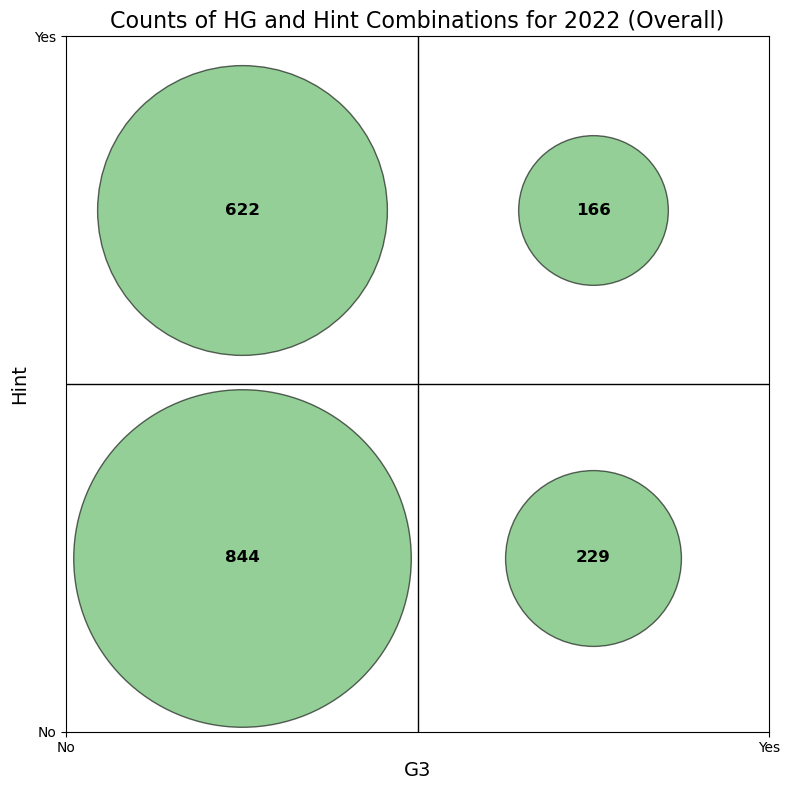

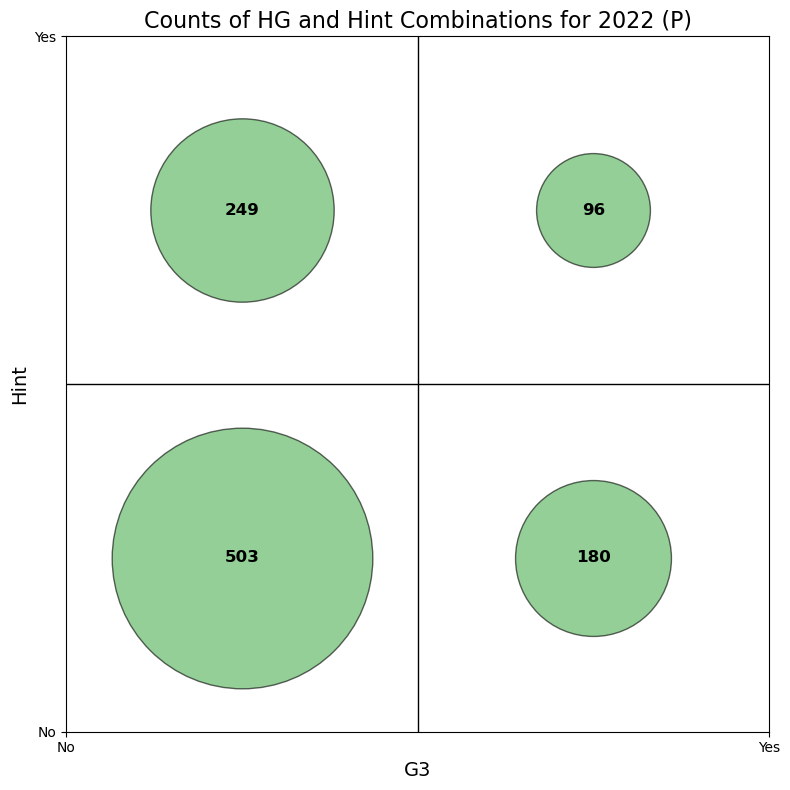

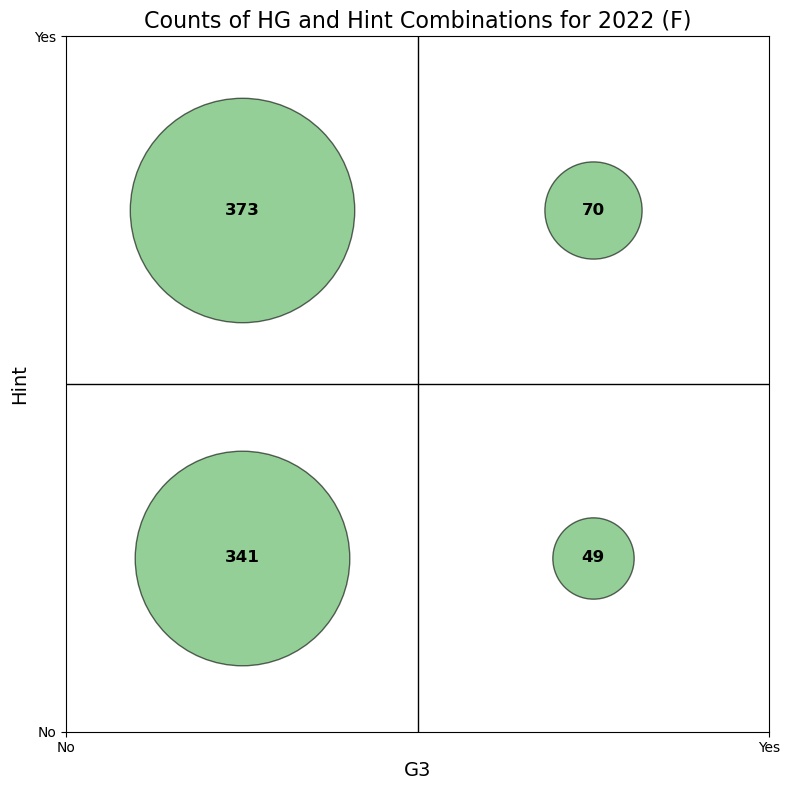

In [25]:
# CHART FUNCTION EXECUTION

# Generate a chart for overall data
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'Hint'], 
    title='Counts of HG and Hint Combinations for 2022 (Overall)'
)

# Generate a chart for the 'P' category in the 'P/F' column
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'Hint'], 
    split_by_column='P/F', 
    filter_value='P', 
    title='Counts of HG and Hint Combinations for 2022 (P)'
)

# Generate a chart for the 'F' category in the 'P/F' column
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'Hint'], 
    split_by_column='P/F', 
    filter_value='F', 
    title='Counts of HG and Hint Combinations for 2022 (F)'
)

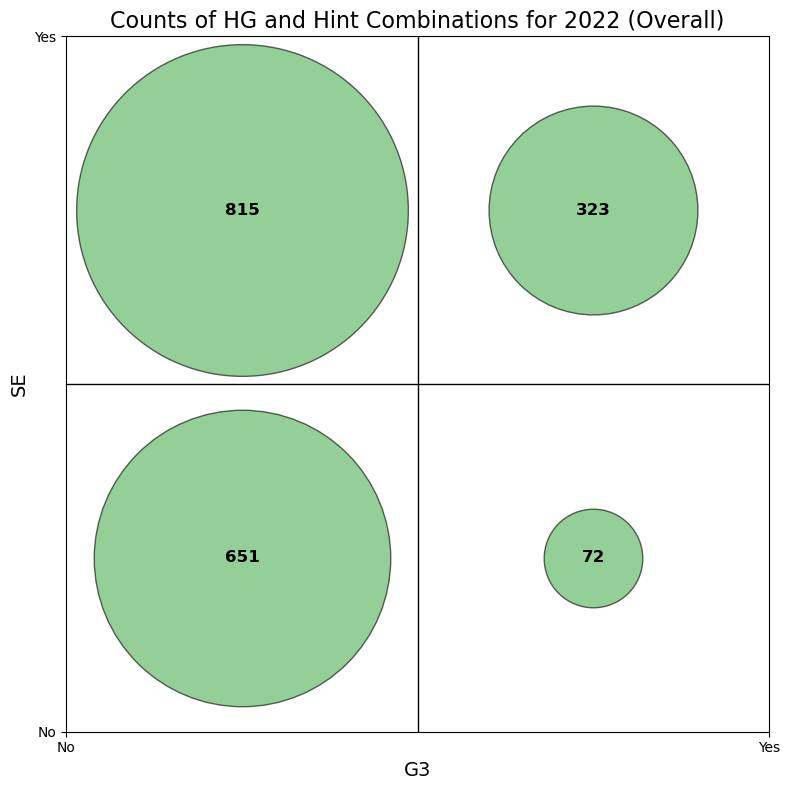

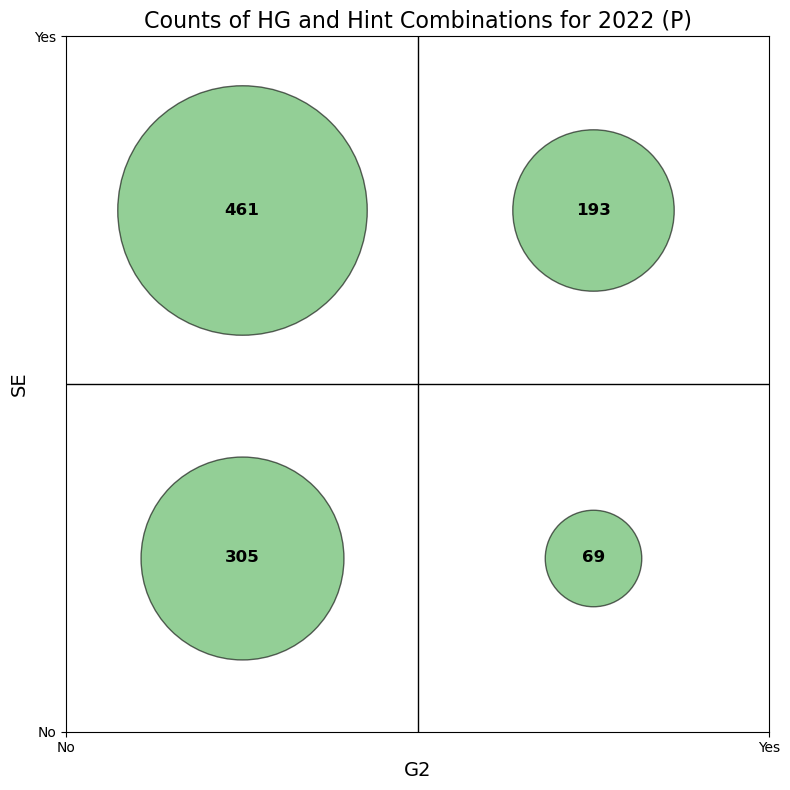

In [26]:
# CHART FUNCTION EXECUTION

# Generate a chart for overall data
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'SE'], 
    title='Counts of HG and Hint Combinations for 2022 (Overall)'
)

# Generate a chart for the 'P' category in the 'P/F' column
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G2', 'SE'], 
    split_by_column='P/F', 
    filter_value='P', 
    title='Counts of HG and Hint Combinations for 2022 (P)'
)

In [27]:
# Filter the data to find companies that experienced both Drop_Sales and have HG

name_filter = df_filter[(df_filter['Drop_Sales'] == 'Yes') & (df_filter['G3'] == 'Yes')][['Name', 'Sales','P/F']]

display(name_filter)

,Name,Sales,P/F
10,"Jastrzębska Spółka Węglowa SA, Jastrzębie–Zdrój","25 770 900,00",P
11,"Polskie Sieci Elektroenergetyczne SA, Konstancin","25 473 210,91",P
12,"Grupa Azoty SA GK, Tarnów","24 657 853,00",P
32,"Shell Polska sp. z o.o, Warszawa","13 424 447,00",F
66,"Grupa Azoty Zakłady Azotowe Puławy SA GK, Puławy","8 898 737,00",P
75,"Węglokoks SA GK, Katowice","7 890 801,00",P
79,"CMC Poland sp. z o.o., Zawiercie","7 220 637,00",F
85,"Polenergia SA GK, Warszawa","7 089 231,00",P
99,"Arcturus Bunker sp. z o.o., Szczecin","6 403 160,60",P
108,"Anwil SA, Włocławek","5 736 650,00",P


In [28]:
# OLS Regression Model
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Filter the data for the year 2022
data_2022 = df_filter[df_filter['Year'] == 2022]

# Remove rows with missing values in the relevant columns
data_2022_cleaned = data_2022.dropna(subset=['P/F', 'G3','Hint','Drop_Sales','Drop_Employment','Starting_Size','Starting_Profit','Human_Capital', 'Letter', 'LSGrowth_2022_2019'])

# Define the dependent variable
y_2022 = data_2022_cleaned['LSGrowth_2022_2019']

# Define the independent variables
X_2022 = data_2022_cleaned[['P/F', 'G3','Hint','Drop_Sales','Drop_Employment','Starting_Size','Starting_Profit','Human_Capital', 'Letter']]

# Convert categorical variables to dummies
X_2022 = pd.get_dummies(X_2022, drop_first=True)

# Add a constant to the model (intercept)
X_2022 = sm.add_constant(X_2022)

# Convert all boolean columns in the DataFrame to integers
for col in X_2022.columns:
    if X_2022[col].dtype == 'bool':
        X_2022[col] = X_2022[col].map({True: 1, False: 0})

# Fit the OLS model
model_2022 = sm.OLS(y_2022, X_2022).fit()

# Show the summary of the regression
print(model_2022.summary())

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X_2022.columns
vif_data['VIF'] = [variance_inflation_factor(X_2022.values, i) for i in range(X_2022.shape[1])]

# Show the VIF results
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:     LSGrowth_2022_2019   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     115.4
Date:                Thu, 10 Oct 2024   Prob (F-statistic):               0.00
Time:                        10:55:28   Log-Likelihood:                -807.83
No. Observations:                1844   AIC:                             1662.
Df Residuals:                    1821   BIC:                             1789.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.1515    